# Problem Set 1 of Non-eq. Statistical Mechanics
Alessio Martini 15621707 

# 2. Implement a code that integrates the equation of motion for a free Brownian particle (i.e. that is not subjected to any external forces). Assume that the dynamics is fully-overdamped.

In this point i've numerically integrated the Langevin equation of motion given by the problem, where i set f(x)=0. 

# Parameters used
Number of simulations = 100  

Number of steps for each simulation = 100   

Discretization of time = 0.01   

tau = 1 : timescale 

m = 1 : mass 

kB = 1.0 : Boltzman constant 

T = 1.0 : Temperature 

In [21]:
# libraries 
import numpy as np
import matplotlib.pyplot as plt
import math
import statistics

# fit
from scipy.optimize import curve_fit

def f(x): # deterministic force
    f = 0
    return f

def test(x, m, q): # Test function with coefficients as parameters
    return m * x + q


In [22]:
# Parametri generali
num_simulations = 100  # Numero di simulazioni
steps = 100         # Numero di passi temporali
dt = 0.01            # Passo temporale
#gamma = 1.0          # Attrito viscoso
tau = 1 # timescale
m = 1 # mass
kB = 1.0            # Cost termica
T = 1.0 # temperatura
#F_deterministic = 0.0  # Forza esterna (ad esempio, 0.0 per ora)

In [23]:
# Funzione per eseguire una singola simulazione del moto di Langevin
def langevin_simulation(simulation_id, steps, dt, kB,T,tau,m):
    mu = 0.0 # mean
    sigma = 1.0 # average
    
    np.random.seed()  # Genera casualità unica per ogni simulazione
    
    # Inizializzazione delle variabili
    x = 0.0  # Posizione iniziale
    #v = 0.0  # Velocità iniziale
    trajectory = [x]  # Tracciamento della traiettoria
    
    # Simulazione iterativa
    for i in range(steps):
        # Equazione di Langevin discreta      
        x = trajectory[i] + dt*(tau/m)*f(trajectory[i]) + math.sqrt(2*kB*T*tau/m)*math.sqrt(dt)*np.random.normal(mu,sigma)
        
        trajectory.append(x)
    
    return np.array(trajectory)

In [24]:
# Esecuzione delle simulazioni
all_simulations = []
for i in range(num_simulations):
    sim_data = langevin_simulation(
        simulation_id=i, steps=steps, dt=dt, kB = kB, T=T, tau=tau, m=m
    )
    all_simulations.append(sim_data)

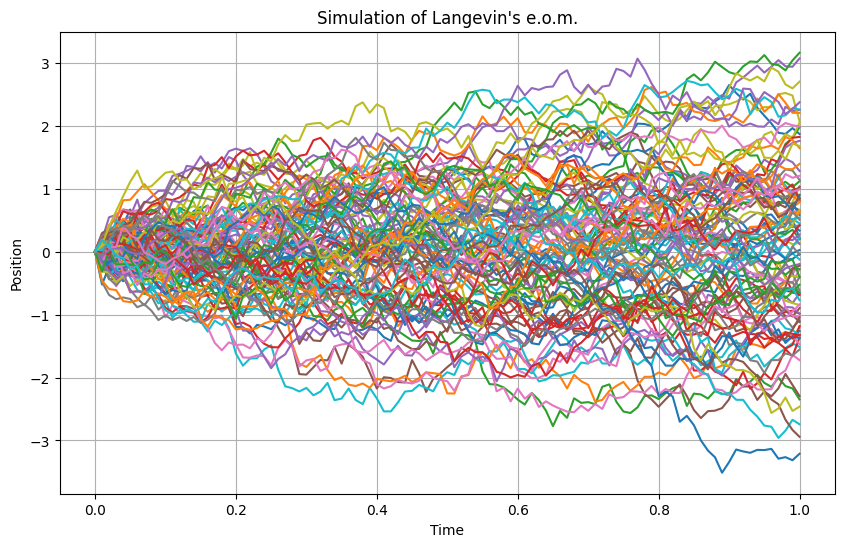

In [25]:
# Plot dei risultati
time = np.arange(steps + 1) * dt  # Array temporale
plt.figure(figsize=(10, 6))
for i, sim_data in enumerate(all_simulations):
    #plt.plot(time, sim_data, label=f"Simulazione {i+1}")
    plt.plot(time, sim_data)

plt.title("Simulation of Langevin's e.o.m.")
plt.xlabel("Time")
plt.ylabel("Position")
#plt.legend()
plt.grid()
plt.show()

# 3. Test your code by letting your free Brownian particle diffuse around in the absence of any potential. Validate the expected scaling (with time t) of the mean square displacement ⟨x2⟩.

In this excercise i expect the MSD to be linearly dependent on time, in fact i'll interpolate the data using a straight line.

In [26]:
# calcolo della media e varianza
media = []
varianza = []

for n in range(steps+1):
    mean_temp = 0.0
    varianza_temp = 0.0

    for i, sim_data in enumerate(all_simulations):
        mean_temp += sim_data[n]
        varianza_temp += math.pow(sim_data[n],2)

    mean_temp = mean_temp/num_simulations
    varianza_temp = varianza_temp/num_simulations
    
    media.append(mean_temp)
    varianza.append(varianza_temp)

In [27]:
# curve_fit() function takes the test-function
# x-data and y-data as argument and returns 
# the coefficients a and b in param and
# the estimated covariance of param in param_cov
param, param_cov = curve_fit(test, time, varianza)

print("Test function coefficients:")
print("m = ", param[0])
print("q = ", param[1])
print("Covariance of coefficients:")
print(param_cov)

test_pt_x = [0,dt*steps]
test_pt_y = [param[1],dt*steps*param[0]]

Test function coefficients:
m =  1.686109351672018
q =  0.11137983493810233
Covariance of coefficients:
[[ 0.00047575 -0.00023787]
 [-0.00023787  0.00015938]]


These above are the values of the fit made by interpolating a straight line, m is the angular coefficient and q the y value when x=0. Notice that this line is plotted in the graph below.

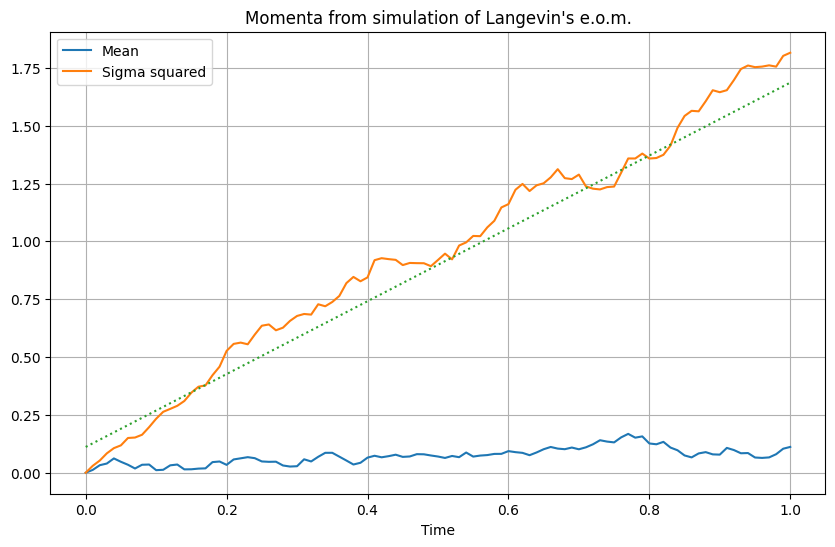

In [28]:
plt.figure(figsize=(10, 6))

plt.plot(time, media, label=f"Mean")
plt.plot(time, varianza, label=f"Sigma squared")
plt.plot(test_pt_x, test_pt_y, linestyle = 'dotted')

plt.title("Momenta from simulation of Langevin's e.o.m.")
plt.xlabel("Time")
#Splt.ylabel("Position")
plt.legend()
plt.grid()
plt.show()

# 4. Measure the diffusion constant D for your free Brownian particle. Next, change the temperature T , and extract the T -dependence of D. Does it follow the prediction we saw in class?

Here i've used the same parametrs as before but i let the temperature T change, and repeated the simulation at the temperatures 1,2,3,...,100.

Here, since the variance of the value increases, i've increased the number of simulations over which I averaged, setting it: num_simulations = 10*Temperature (approximating the temperature at the closest integer)

In [29]:
# estrazione dipendenza D - T

Temp_array = np.linspace(1, 100, 100, endpoint = True) 
D_array = []
time = np.arange(steps + 1) * dt  # Array temporale

for t in Temp_array:
    # Parametri generali
    num_simulations = 10*int(t)  # Numero di simulazioni
    steps = 100         # Numero di passi temporali
    dt = 0.01            # Passo temporale
    tau = 1 # timescale
    m = 1 # mass
    kB = 1.0            # Cost termica
    T = t # temperatura
    
    # Esecuzione delle simulazioni
    all_simulations = []
    for i in range(num_simulations):
        sim_data = langevin_simulation(
            simulation_id=i, steps=steps, dt=dt, kB = kB, T=T, tau=tau, m=m # qui e' dove cambia T=i
        )
        all_simulations.append(sim_data)

    # calcolo della media e varianza
    media = []
    varianza = []
    
    for n in range(steps+1):
        mean_temp = 0.0
        varianza_temp = 0.0
    
        for i, sim_data in enumerate(all_simulations):
            mean_temp += sim_data[n]
            varianza_temp += math.pow(sim_data[n],2)
    
        mean_temp = mean_temp/num_simulations
        varianza_temp = varianza_temp/num_simulations
        
        media.append(mean_temp)
        varianza.append(varianza_temp)

    param, param_cov = curve_fit(test, time, varianza)

    D_array.append(param[0]/2)

In [30]:
# curve_fit() function takes the test-function
# x-data and y-data as argument and returns 
# the coefficients a and b in param and
# the estimated covariance of param in param_cov
param, param_cov = curve_fit(test, Temp_array, D_array)

print("Test function coefficients:")
print("m = ", param[0])
print("q = ", param[1])
print("Covariance of coefficients:")
print(param_cov)

test_pt_x = [0,Temp_array[-1]]
test_pt_y = [param[1],Temp_array[-1]*param[0]]

Test function coefficients:
m =  1.007947257087659
q =  -0.5600499480206349
Covariance of coefficients:
[[ 1.39128327e-04 -7.02598055e-03]
 [-7.02598055e-03  4.70740658e-01]]


Here we can see again the values of the parameters of the fitting straight line. Where D is exactly the angular coefficient m.

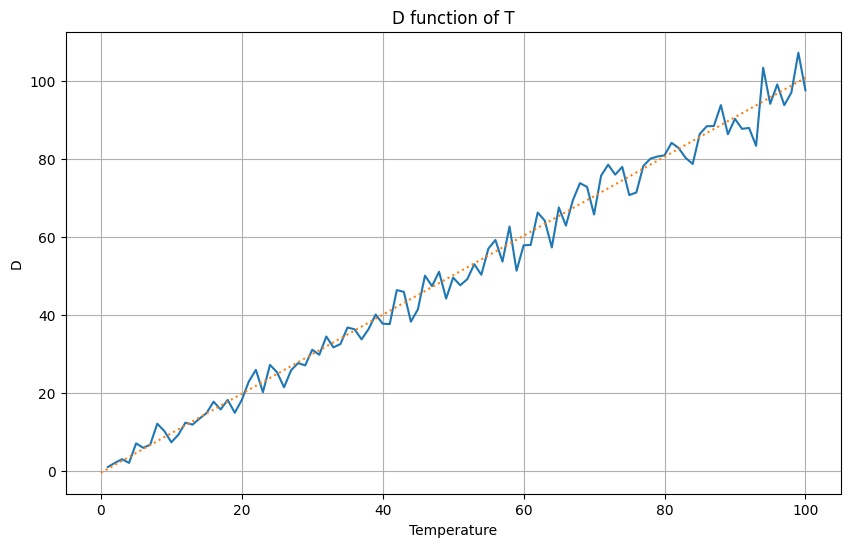

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(Temp_array, D_array)
plt.plot(test_pt_x, test_pt_y, linestyle = 'dotted')

plt.title("D function of T")
plt.xlabel("Temperature")
plt.ylabel("D")
#plt.legend()
plt.grid()
plt.show()

As we expected the dependency of D from T is linear, and in my specific case D=1 becouse i've set all the relevant parameters to 1.

# 5. Now introduce the potential Eq. (1.1) into your simulation, set A = 0, and study the long time (stationary) limit of the probability distribution p(x; T ) for 3 different temperatures T . What do you find? Can you explain it based on your knowledge of equilibrium stat-phys?

Here i've reintroduced the deterministic force in the simulation keeping only the quadratic term.

As we expected, at higher temperatures the probability distribution is much more spread over space than at lower ones, this because particles have higher mean kinetic energy, managing to reach region of the space where the harmonic potential is stronger.

# Parameters of the simulation
The temperature at which i've studied the probabilistic distribution are T=[1,2,4,8,16,32,64,128].

num_simulations = 10000  # Number of simulations

steps = 100  # time steps       
    
dt = 0.01            # time discretization

tau = 1 # timescale
    
m = 1 # mass
    
kB = 1.0 

In [32]:
def f(x): # deterministic force
    k = 1
    A = 0
    f = -k*x - 4*A*math.pow(x,3)
    return f

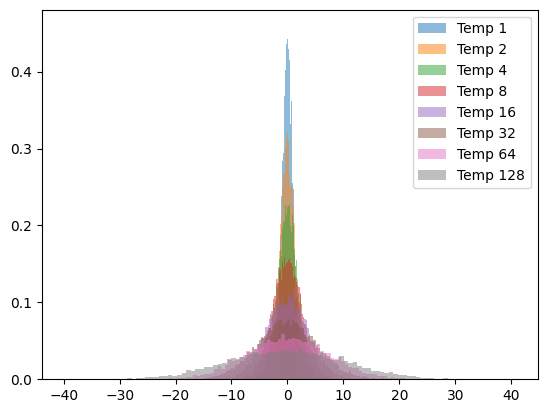

In [33]:
Temp_array = [1,2,4,8,16,32,64,128]
#D_array = []
time = np.arange(steps + 1) * dt  # Array temporale

for t in Temp_array:
    # Parametri generali
    num_simulations = 10000  # Numero di simulazioni
    steps = 100         # Numero di passi temporali
    dt = 0.01            # Passo temporale
    #gamma = 1.0          # Attrito viscoso
    tau = 1 # timescale
    m = 1 # mass
    kB = 1.0            # Cost termica
    T = t # temperatura
    #F_deterministic = 0.0  # Forza esterna (ad esempio, 0.0 per ora)
    
    # Esecuzione delle simulazioni
    all_simulations = []
    for i in range(num_simulations):
        sim_data = langevin_simulation(
            simulation_id=i, steps=steps, dt=dt, kB = kB, T=T, tau=tau, m=m # qui e' dove cambia T=i
        )
        all_simulations.append(sim_data)

    data = []
    for i in range(num_simulations):
        data.append(all_simulations[i][-1])
    
    # costruzione dell'istogramma
    plt.hist(data, label=f"Temp {t}",alpha=.5, bins=100, density=True)

plt.legend()
plt.show()

# 6. Explain the reasoning behind how you determined the integration time-step ∆t in your code for your Brownian particle subjected to the potential V (x) of Eq. (1.1). Construct a timescale from the parameters of the problem (other than τ ), with respect to which your integration time-step can be compared.

The time discretization must be smaller than any physical timescale in the system: specifically, the damping timescale (associated with the random process) and the timescale of the harmonic potential. This ensures that no information is lost due to the time discretization when numerically solving the differential equation.

Using dimensional analysis, we observe that the elastic constant \( k \) of the potential has dimensions of energy per unit length squared \([E/L^2]\). To find the characteristic frequency (or equivalently, the period) of the oscillator, we combine \( k \) with the mass \( m \), which has dimensions of energy times time squared per unit length squared \([E \cdot T^2 / L^2]\). This leads to the characteristic timescale \( \sqrt{m/k} \).

In our specific case, the damping timescale \( \tau_{\text{damping}} = 1 \), and the timescale of the harmonic oscillator \( \sqrt{m/k} = 1 \). Therefore, choosing \( \Delta t = 0.01 \) as the integration time step is reasonable.

# 7. Next, set A = 1, and study statistics of the time τ1 it takes for the Brownian particle to first reach the top of the barrier at x = ±xb. Perform this investigation while systematically changing the temperature T and the height of the barrier ∆(k), the latter can be varied by tuning the parameter k. Always work in the range T ≪ ∆.

Here i've redefined the deterministic force, reintroducing a x^4 term.

In [34]:
def f(x,k): # deterministic force
    #k = 1
    A = 1
    f = -k*x - 4*A*math.pow(x,3)
    return f

In [35]:
Temp_array = np.linspace(1,5,50)
k_array = np.linspace(1,3,5)
exit_time = []
mean_exit_time = [] # for each k
mean_exit_time_list = []

num_simulations = 100  # Numero di simulazioni
tau = 1 # timescale
m = 1 # mass
kB = 1.0            # Cost termica => energia e temperatura sono uguali
dt = 0.01            # Passo temporale

mu = 0.0
sigma = 1.0

for k in k_array:
    mean_exit_time = []
    for T in Temp_array:
        exit_time = [] # for each k
        for i in range(num_simulations):
            np.random.seed()  # Genera casualità unica per ogni simulazione
            x = 0.0  # Posizione iniziale
            t = 0.0

            # Esecuzione delle simulazioni
            while math.pow(x,2) < k/4:
                x +=  dt*(tau/m)*f(x,k) + math.sqrt(2*kB*T*tau/m)*math.sqrt(dt)*np.random.normal(mu,sigma)
                t += dt
    
            exit_time.append(t)

        mean_exit_time.append(statistics.mean(exit_time)) # fixed k and varying T

    mean_exit_time_list.append(mean_exit_time)



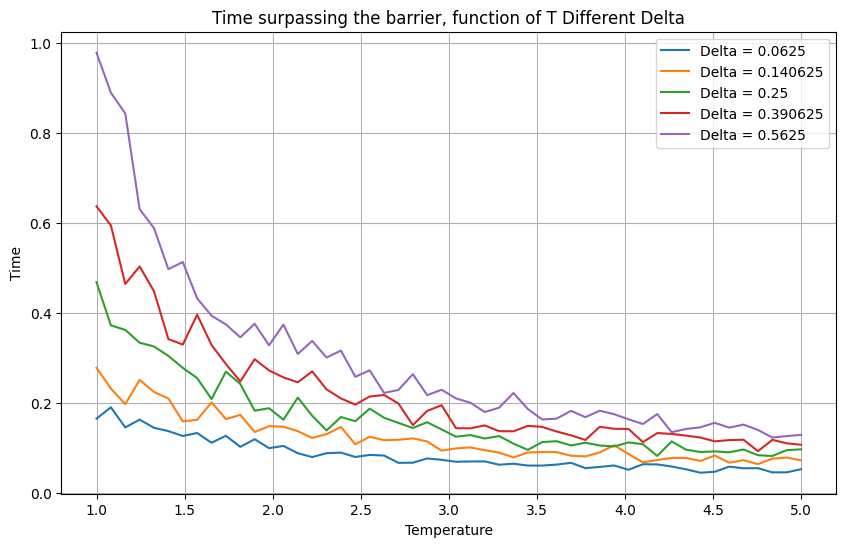

In [36]:
plt.figure(figsize=(10, 6))
for i, mean_exit_time in enumerate(mean_exit_time_list):
    plt.plot(Temp_array[:len(mean_exit_time)], mean_exit_time, label=f"Delta = {math.pow(k_array[i],2)/16}")

plt.title("Time surpassing the barrier, function of T Different Delta")
plt.xlabel("Temperature")
plt.ylabel("Time")
#plt.yscale("log")
plt.legend()
plt.grid()
plt.savefig("Time surpassing the barrier_function of T and Delta.png")
plt.show()


For the above simualtion:
# Parameters
number of simulations = 100  

tau = 1 # timescale

m = 1 # mass

kB = 1.0            # boltzman constant

dt = 0.01            # time discretization

In [37]:
Temp_array = np.linspace(1,16,6)
k_array = np.linspace(1,15,30)
exit_time = []
mean_exit_time = [] # for each k
mean_exit_time_list = []

num_simulations = 200  # Numero di simulazioni
tau = 1 # timescale
m = 1 # mass
kB = 1.0            # Cost termica => energia e temperatura sono uguali
dt = 0.01            # Passo temporale

mu = 0.0
sigma = 1.0

for T in Temp_array:
    mean_exit_time = []
    for k in k_array:
        exit_time = [] # for each k
        for i in range(num_simulations):
            np.random.seed()  # Genera casualità unica per ogni simulazione
            x = 0.0  # Posizione iniziale
            t = 0.0

            # Esecuzione delle simulazioni
            while math.pow(x,2) < k/4:
                x +=  dt*(tau/m)*f(x,k) + math.sqrt(2*kB*T*tau/m)*math.sqrt(dt)*np.random.normal(mu,sigma)
                t += dt
    
            exit_time.append(t)

        mean_exit_time.append(statistics.mean(exit_time)) # fixed k and varying T
        if statistics.mean(exit_time) > 2:
            break

    mean_exit_time_list.append(mean_exit_time)



In [38]:
delta_array = []
for i in k_array:
    delta_array.append(math.pow(i,2)/16)

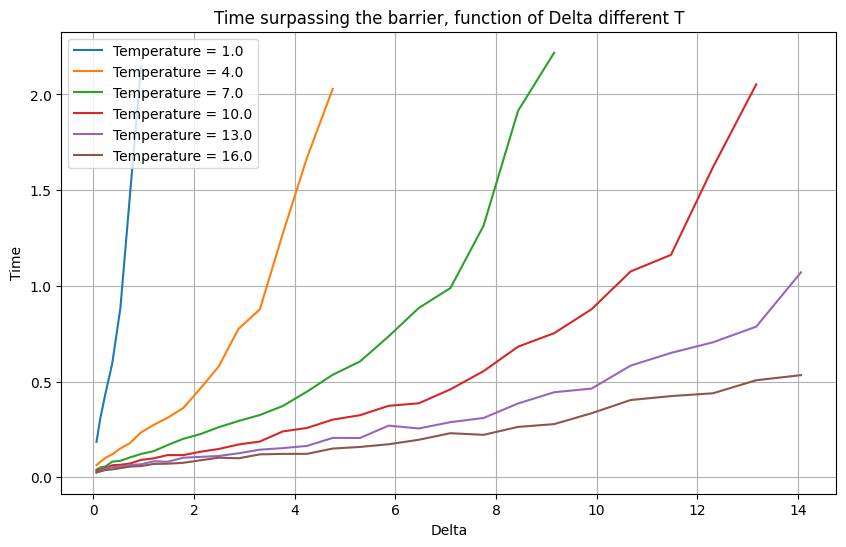

In [39]:
plt.figure(figsize=(10, 6))
for i, mean_exit_time in enumerate(mean_exit_time_list):
    plt.plot(delta_array[:len(mean_exit_time)], mean_exit_time, label=f"Temperature = {Temp_array[i]}")

plt.title("Time surpassing the barrier, function of Delta different T")
plt.xlabel("Delta")
plt.ylabel("Time")
#plt.yscale("log")
plt.legend()
plt.grid()
plt.savefig("Time surpassing the barrier, function of Delta different T.png")
plt.show()

It is not feasible to work in the regime \( T \ll \Delta \) because this makes the computation extremely expensive. Therefore, all simulations were conducted in the regime \( T \geq \Delta \), as can be seen from the plots. Specifically, I worked in the range where \( T \) was as small as possible (within the limitations of my computer) relative to \( \Delta \). Additionally, simulations were performed only in the region where the mean first-passage time was not excessively long, allowing for better visualization and comparison of the graphs across different temperatures.

# 8. Find the functional dependence of ⟨τ1⟩ on ∆ and T .

The behavior appears to be exponential in both the dependencies for bigh enough values of x (T and Delta); however, it cannot be a purely exponential dependence on \( T \) since the mean first-passage time diverges as \( T \to 0 \). Similarly, cannot be purely exponential in Delta because near zero the mean time goes to zero, in fact looking at the graphs the behaviour of the mean time function of Delta near zero seems to be linear. 

# 9. bonus: At what ∆/T does the scaling you found break down?


Here I'm not sure about the answer, but i think that the behaviour change drastically when the temperature is not much smaller than Delta, and the particles have high probability to escape from the quadratic potential. Then the ratio Delta/T = 1 should separate two different behaviuors of the system: the first in which the particle are mostly confined, and the second where the spread among all the space.

# EXTRA PICTURES for ex 7: different axes choices

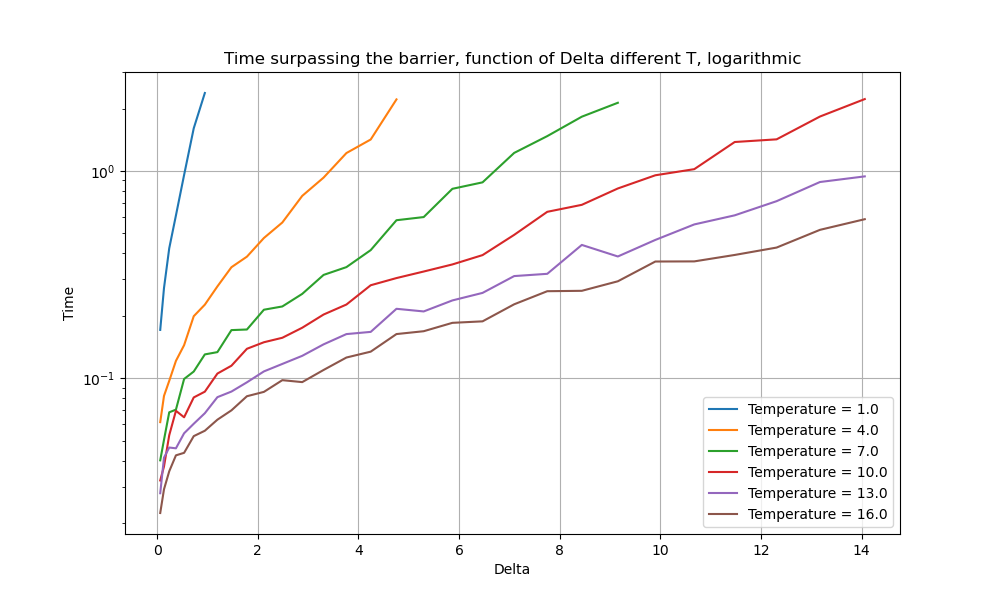
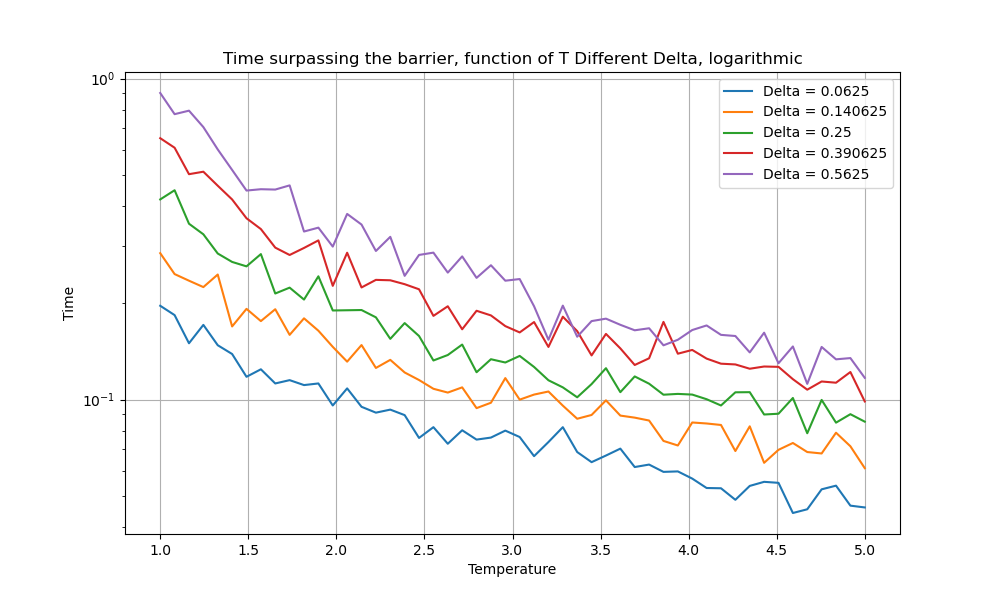
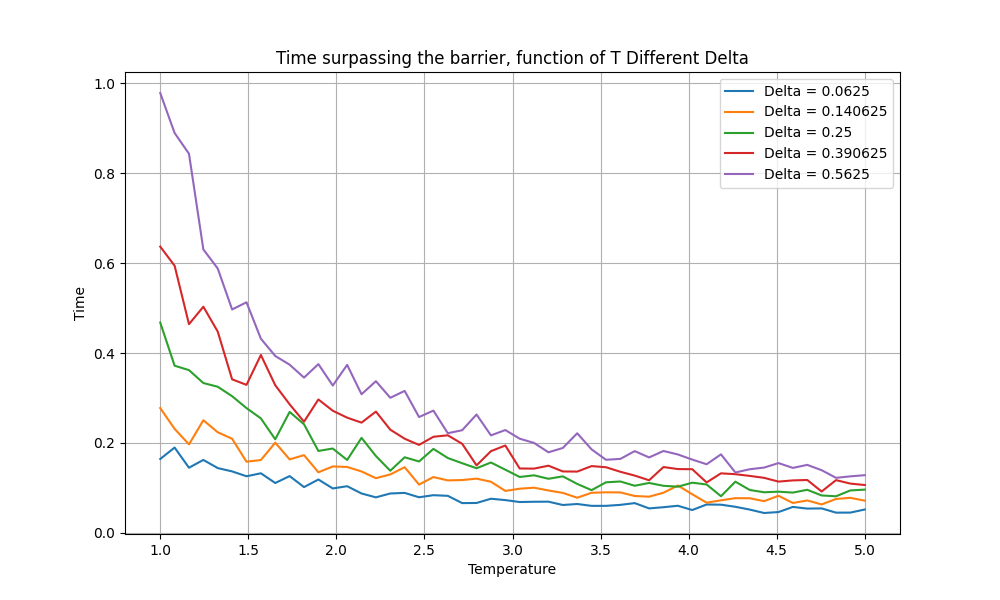
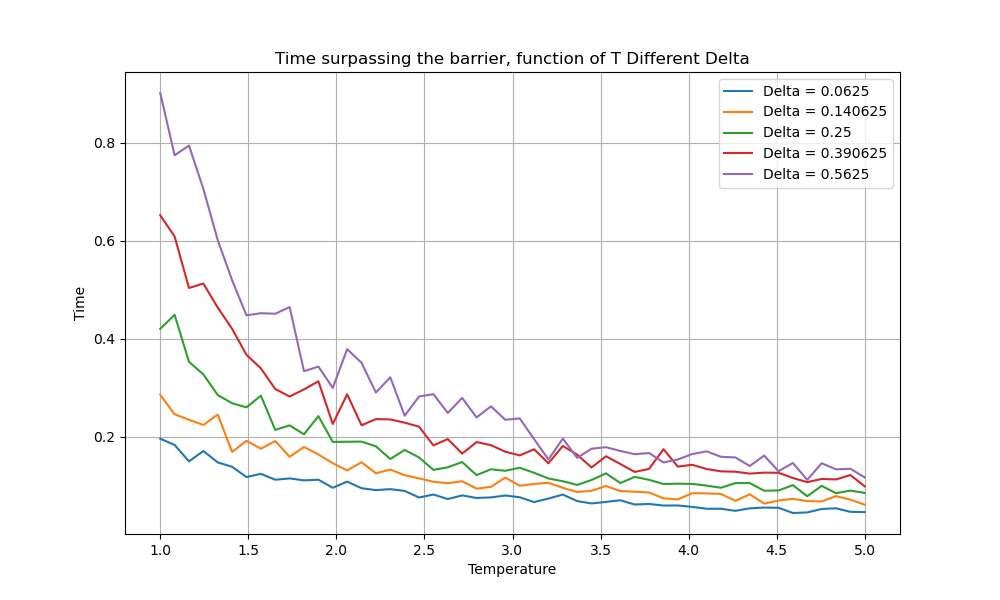
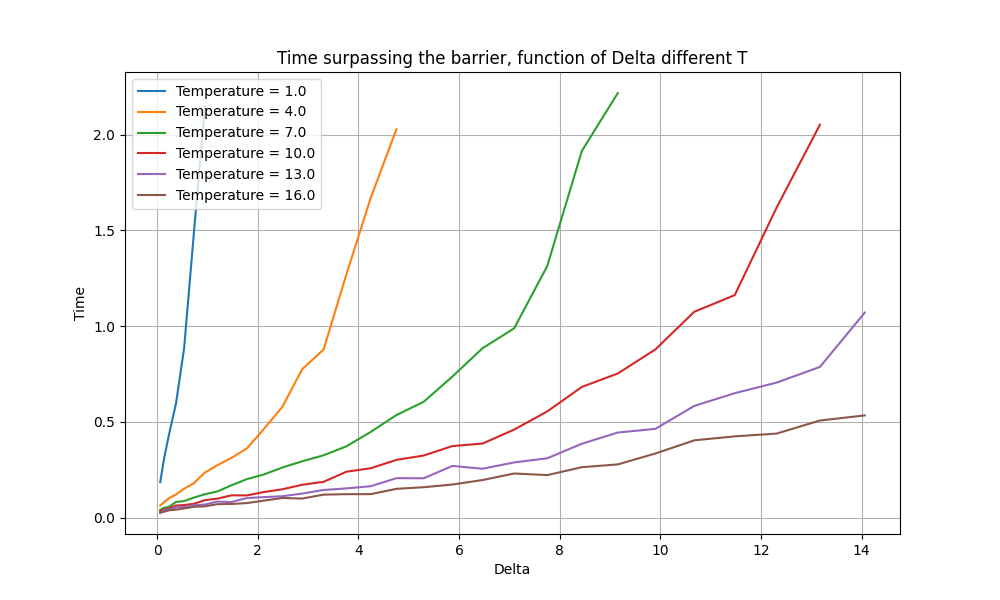